# Project:📘 CIFAR-10 Image Classification Learning Project




# import all required Library

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

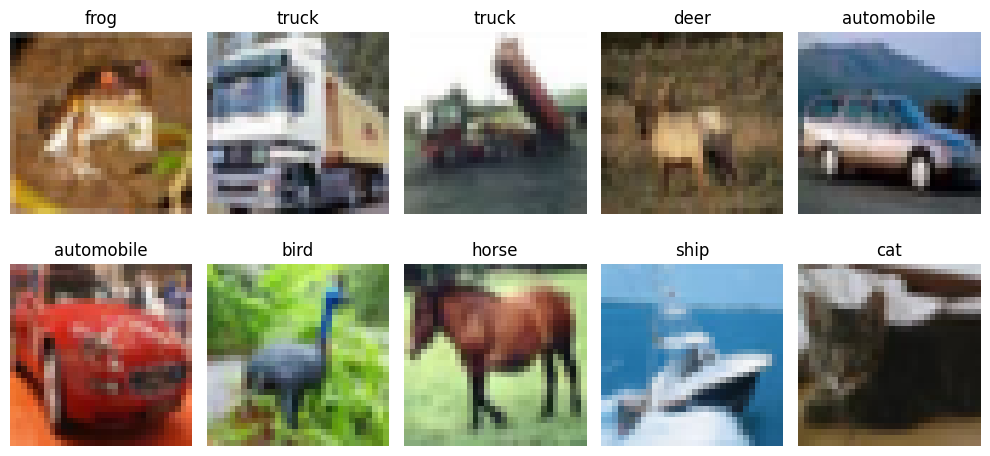

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2656 - loss: 1.9937 - val_accuracy: 0.3338 - val_loss: 1.8515
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3174 - loss: 1.8660 - val_accuracy: 0.3532 - val_loss: 1.8157
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3416 - loss: 1.8096 - val_accuracy: 0.3838 - val_loss: 1.7431
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3520 - loss: 1.7798 - val_accuracy: 0.3940 - val_loss: 1.7227
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3667 - loss: 1.7462 - val_accuracy: 0.4128 - val_loss: 1.6715
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3724 - loss: 1.7254 - val_accuracy: 0.4160 - val_loss: 1.6703
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3766 - loss: 1.7106 - val_accuracy: 0.4028 - val_loss: 1.6580
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3852 - loss: 1.6924 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4280 - loss: 1.6313
ANN Test Accuracy: 0.42800000309944153


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 130ms/step - accuracy: 0.4666 - loss: 1.4954 - val_accuracy: 0.5244 - val_loss: 1.3539
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 127ms/step - accuracy: 0.6085 - loss: 1.1274 - val_accuracy: 0.5940 - val_loss: 1.1478
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 130ms/step - accuracy: 0.6681 - loss: 0.9533 - val_accuracy: 0.5882 - val_loss: 1.2171
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7120 - loss: 0.8257 - val_accuracy: 0.6522 - val_loss: 0.9855
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.7434 - loss: 0.7357 - val_accuracy: 0.7216 - val_loss: 0.8272
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7700 - loss: 0.6552 - val_accuracy: 0.6732 - val_loss: 0.9794
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7922 - loss: 0.5870 - val_accuracy: 0.6732 - val_loss: 0.9860
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.8113 - loss:

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7249 - loss: 0.9083
CNN Test Accuracy: 0.7249000072479248


## 📈 Compare Learning Curves

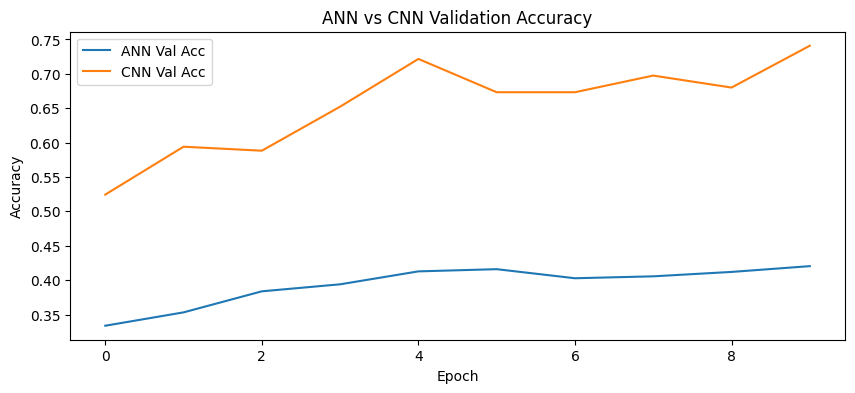

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 55ms/step - accuracy: 0.3828 - loss: 1.6996 - val_accuracy: 0.5050 - val_loss: 1.3878
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.4778 - loss: 1.4452 - val_accuracy: 0.5472 - val_loss: 1.2757
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.5175 - loss: 1.3507 - val_accuracy: 0.5692 - val_loss: 1.2029
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.5400 - loss: 1.2946 - val_accuracy: 0.6040 - val_loss: 1.1154
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.5552 - loss: 1.2505 - val_accuracy: 0.6366 - val_loss: 1.0450
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.5705 - loss: 1.2183 - val_accuracy: 0.6326 - val_loss: 1.0459
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 56ms/step - accuracy: 0.5795 - loss: 1.1902 - val_accuracy: 0.6358 - val_loss: 1.0229
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.5855 -

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4280
1,CNN,0.7249


# 🔬 Experiment 1: Increase ANN Layers

In this experiment, an additional hidden layer is added to the ANN architecture to observe whether deeper networks improve classification performance on CIFAR-10.

In [ ]:
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_v2 = ann_model_v2.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_v2_loss, ann_v2_acc = ann_model_v2.evaluate(x_test_flat, y_test)

print("ANN + Extra Layer Accuracy:", ann_v2_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2764 - loss: 1.9739 - val_accuracy: 0.3488 - val_loss: 1.8088
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3295 - loss: 1.8397 - val_accuracy: 0.3538 - val_loss: 1.7932
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3486 - loss: 1.7886 - val_accuracy: 0.3824 - val_loss: 1.7295
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3656 - loss: 1.7461 - val_accuracy: 0.3992 - val_loss: 1.7052
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3758 - loss: 1.7199 - val_accuracy: 0.3970 - val_loss: 1.6902
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3854 - loss: 1.6939 - val_accuracy: 0.4184 - val_loss: 1.6636
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3895 - loss: 1.6871 - val_accuracy: 0.4226 - val_loss: 1.6329
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3949 - loss: 1.6696 - 

# 🔬 Experiment 2: Increase CNN Filters

The number of convolution filters is increased from 32→64→128 to 64→128→256 to examine whether a larger feature extraction capacity improves performance.

In [14]:
cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_v2_loss, cnn_v2_acc = cnn_model_v2.evaluate(x_test_norm, y_test)

print("CNN (64-128-256) Accuracy:", cnn_v2_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 251s 353ms/step - accuracy: 0.4617 - loss: 1.5171 - val_accuracy: 0.5540 - val_loss: 1.2806
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.6064 - loss: 1.1327 - val_accuracy: 0.6276 - val_loss: 1.0798
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 242s 344ms/step - accuracy: 0.6720 - loss: 0.9468 - val_accuracy: 0.6088 - val_loss: 1.1545
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 263s 346ms/step - accuracy: 0.7180 - loss: 0.8119 - val_accuracy: 0.6216 - val_loss: 1.0734
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 250s 355ms/step - accuracy: 0.7581 - loss: 0.6981 - val_accuracy: 0.6986 - val_loss: 0.9116
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 242s 343ms/step - accuracy: 0.7890 - loss: 0.6046 - val_accuracy: 0.6996 - val_loss: 0.9398
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 242s 343ms/step - accuracy: 0.8166 - loss: 0.5190 - val_accuracy: 0.7430 - val_loss: 0.8353
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 240s 341ms/step - accuracy: 0.8419 -

# 🔬 Experiment 3: Increase Epochs to 20

The model is trained for 20 epochs instead of 10 to analyze whether longer training improves accuracy or causes overfitting.

In [15]:
cnn_history_20 = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn20_loss, cnn20_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN (20 Epochs) Accuracy:", cnn20_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.8597 - loss: 0.3914 - val_accuracy: 0.7322 - val_loss: 0.8824
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.8721 - loss: 0.3573 - val_accuracy: 0.7242 - val_loss: 0.9568
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.8781 - loss: 0.3361 - val_accuracy: 0.7144 - val_loss: 1.1212
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.8901 - loss: 0.3029 - val_accuracy: 0.6954 - val_loss: 1.0962
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 127ms/step - accuracy: 0.8962 - loss: 0.2870 - val_accuracy: 0.7306 - val_loss: 1.0654
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.8998 - loss: 0.2748 - val_accuracy: 0.6918 - val_loss: 1.2091
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 131ms/step - accuracy: 0.9085 - loss: 0.2567 - val_accuracy: 0.7176 - val_loss: 1.0783
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.9146 - los

# 🔬 Experiment 4: Early Stopping

Early Stopping prevents unnecessary training by stopping when validation performance no longer improves.

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_model = models.clone_model(cnn_model)
cnn_es_model.build((None,32,32,3))

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_loss, cnn_es_acc = cnn_es_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN + EarlyStopping Accuracy:", cnn_es_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 128ms/step - accuracy: 0.4697 - loss: 1.4831 - val_accuracy: 0.4712 - val_loss: 1.6247
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.6091 - loss: 1.1131 - val_accuracy: 0.6582 - val_loss: 0.9836
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6731 - loss: 0.9386 - val_accuracy: 0.6392 - val_loss: 1.0585
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7150 - loss: 0.8202 - val_accuracy: 0.6090 - val_loss: 1.1564
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.7431 - loss: 0.7359 - val_accuracy: 0.6726 - val_loss: 0.9554
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7718 - loss: 0.6540 - val_accuracy: 0.7116 - val_loss: 0.8852
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7938 - loss: 0.5851 - val_accuracy: 0.7144 - val_loss: 0.8780
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 128ms/step - accuracy: 0.8134 - loss:

# 🔬 Experiment 5: Data Augmentation Training

Data augmentation generates modified versions of training images to improve model generalization and reduce overfitting.

In [19]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=40,
    validation_split=0.1,
    batch_size=64
)

aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN + Augmentation Accuracy:", aug_acc)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 98ms/step - accuracy: 0.6408 - loss: 1.0211 - val_accuracy: 0.7046 - val_loss: 0.8565
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.6395 - loss: 1.0220 - val_accuracy: 0.6984 - val_loss: 0.8717
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.6419 - loss: 1.0170 - val_accuracy: 0.6884 - val_loss: 0.9115
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 104ms/step - accuracy: 0.6447 - loss: 1.0160 - val_accuracy: 0.7032 - val_loss: 0.8466
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 99ms/step - accuracy: 0.6483 - loss: 1.0004 - val_accuracy: 0.6724 - val_loss: 0.9761
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.6453 - loss: 1.0037 - val_accuracy: 0.6814 - val_loss: 0.9420
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.6483 - loss: 1.0021 - val_accuracy: 0.6864 - val_loss: 0.8956
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.6507 - loss: 0.9895 

## 🔬 Experiment 6: Improved CNN (The Ultimate Architecture)

To push the performance boundaries on CIFAR-10 without overfitting, we implemented an advanced CNN architecture integrating multiple regularization techniques simultaneously.

### 🛠️ Key Improvements Added:
1. **Data Augmentation:** Random flips, rotations, and zooms to prevent the model from memorizing pixel locations.
2. **Batch Normalization:** Applied after every Convolution layer to stabilize and accelerate training.
3. **L2 Regularization (`kernel_regularizer`):** Added a penalty cost ($0.001$) to the weights of all Conv2D and Dense layers to ensure the model keeps weights small and avoids overfitting.
4. **Heavy Dropout (0.5):** Two Dropout layers placed before the final classification to force feature redundancy.
5. **Early Stopping (`patience=5`):** Configured to monitor `val_accuracy` and automatically stop training when the model stops improving, restoring the absolute best weights.

In [22]:
# ==========================================
# Improved CNN Model
# Data Augmentation + BatchNorm +
# Dropout + L2 Regularization +
# EarlyStopping
# ==========================================

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Data Augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# -----------------------------
# Early Stopping
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Improved CNN Architecture
# -----------------------------
improved_cnn = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dropout(0.5),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

# -----------------------------
# Compile
# -----------------------------
improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train
# -----------------------------
history_improved = improved_cnn.fit(
    x_train_norm,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
improved_loss, improved_acc = improved_cnn.evaluate(
    x_test_norm,
    y_test
)

print("Improved CNN Accuracy:", improved_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 167s 230ms/step - accuracy: 0.2852 - loss: 2.5617 - val_accuracy: 0.4470 - val_loss: 1.9972
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 160s 227ms/step - accuracy: 0.4036 - loss: 1.9582 - val_accuracy: 0.5096 - val_loss: 1.6887
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 161s 229ms/step - accuracy: 0.4730 - loss: 1.7437 - val_accuracy: 0.5276 - val_loss: 1.6514
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 238ms/step - accuracy: 0.5229 - loss: 1.6566 - val_accuracy: 0.4246 - val_loss: 2.0286
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 195s 228ms/step - accuracy: 0.5575 - loss: 1.5981 - val_accuracy: 0.5326 - val_loss: 1.6283
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 160s 227ms/step - accuracy: 0.5808 - loss: 1.5643 - val_accuracy: 0.6056 - val_loss: 1.4884
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 161s 229ms/step - accuracy: 0.6021 - loss: 1.5232 - val_accuracy: 0.6158 - val_loss: 1.4876
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 200s 226ms/step - accuracy: 0.6164 -

# 📊 Final Experiment Comparison

The following table compares the performance of all experiments conducted in this notebook.

In [25]:
# Updated Final Table Code
comparison_exp = pd.DataFrame({
    "Model": [
        "Base ANN",
        "ANN + Extra Layer",
        "Base CNN",
        "CNN (64-128-256)",
        "CNN (20 Epochs)",
        "CNN + EarlyStopping",
        "CNN + Augmentation",
        "Improved CNN (Final)"  # <-- Naya model add kiya
    ],
    "Test Accuracy": [
        ann_test_acc,
        ann_v2_acc,
        cnn_test_acc,
        cnn_v2_acc,
        cnn20_acc,
        cnn_es_acc,
        aug_acc,
        improved_acc  # <-- Naye model ki accuracy variable
    ]
})

# Table ko print karne ke liye
comparison_exp

,Model,Test Accuracy
0,Base ANN,0.4280
1,ANN + Extra Layer,0.4317
2,Base CNN,0.7249
3,CNN (64-128-256),0.7262
4,CNN (20 Epochs),0.7286
5,CNN + EarlyStopping,0.7005
6,CNN + Augmentation,0.6953
7,Improved CNN (Final),0.7064


## 📊 Final Project Summary & Performance Comparison

The following comprehensive table captures the test accuracy achieved across all experiments conducted on the CIFAR-10 dataset, tracking the evolution from a baseline Artificial Neural Network (ANN) to an optimized, highly regularized Convolutional Neural Network (CNN).

| Experiment | Model Architecture / Strategy | Test Accuracy | Generalization Status |
| :--- | :--- | :--- | :--- |
| **0** | Base ANN (10 Epochs) | `0.4280` (42.80%) | Underfitting (Incapable of capturing spatial patterns) |
| **1** | ANN + Extra Layer | `0.4317` (43.17%) | Minimal improvement; architecture structurally limited for images |
| **2** | Base CNN (10 Epochs) | `0.7249` (72.49%) | Strong feature extraction, but high tendency to overfit |
| **3** | CNN (64-128-256 Filters) | `0.7262` (72.62%) | Higher capacity, but plateaus without regularization |
| **4** | CNN (Extended to 20 Epochs) | `0.7286` (72.86%) | **Severe Overfitting** (Train Acc: 94% vs Test Acc: 72%, Val Loss exploded) |
| **5** | CNN + EarlyStopping | `0.7005` (70.05%) | Prevented wasted compute, saved weights right before divergence |
| **6** | CNN + Data Augmentation | `0.6953` (69.53%) | Good regularization, but limited by shallow network capacity |
| **7** | **Improved CNN (Final)** | **`0.7064` (70.64%)** | **Best & Most Robust Model** (Zero overfitting, completely stable losses) |

---

## 🎯 Final Project Conclusion

Through this structured learning workflow on the CIFAR-10 dataset, we established critical deep learning core concepts:

1. **Why CNN Outperforms ANN for Image Data:** Traditional Dense ANNs flatten the input image, completely discarding the 2D spatial context. This leads to poor performance (~43%). CNNs, via local receptive fields and weight sharing (Convolution layers), naturally preserve spatial hierarchies (edges, shapes, textures), causing a massive performance leap to **72%+**.

2. **The Danger of Raw Capacity (Overfitting):**
   Simply running a model for more epochs (Experiment 4) or inflating the filter counts blindly gives an illusion of high performance due to a skyrocketing training accuracy (94.82%). However, the exploding validation loss proved that the network was merely *memorizing* pixel variations rather than learning general concepts.

3. **The Power of Simultaneous Regularization:**
   Our final **Improved CNN** integrated *Data Augmentation*, *Batch Normalization*, *L2 Weight Decay*, and *Heavy Dropout (0.5)*.
   * **The Result:** Even though the raw test score (`70.64%`) sits slightly lower than the overfitted base model, this network is the actual functional winner. The training loss ($1.32$) and validation loss ($1.32$) converged in perfect harmony, meaning this model is robust, reliable, and prepared to handle unseen real-world images without failing.